In [ ]:
# Install the repository-pinned notebook dependencies once per environment.
%pip install -r requirements.txt

# Dataset and previous-model analysis

- **Source:** `ECPE_Synthetic_Journal_Dataset_v3.xlsx`, `Pairs` sheet; 438 labeled emotion-cause pairs across 350 journal entries. The `Entries` sheet has 350 full-text records. The pair columns are `entry_id`, `emotion_clause`, `emotion`, `cause_clause`, `cause`, `ner`, `aspect` (target), and `annotator`.
- **Labels:** `none` 87, `studies_work` 77, `friends` 55, `health` 46, `other` 40, `money` 36, `family` 34, `self` 34, `relationships` 29. This is a 3:1 largest-to-smallest class ratio; no class is large for fine-tuning a 125M-parameter model. Labels are marked LLM-draft in the workbook, so label noise is also a concern.
- **Existing preprocessing/model:** the earlier notebook fills missing clause strings with empty text, concatenates emotion/cause clauses and metadata, then compares TF-IDF/logistic regression, LinearSVC, and an MLP over word (1-3 gram) plus character (3-5 gram) TF-IDF features. The best prior baseline was an MLP with hidden layer `(64,)`, `alpha=0.1`, and learning rate `0.001`.
- **Previously measured:** on a grouped 80/20 holdout (348 train / 90 test pairs), LinearSVC scored 73.33% accuracy / 0.6573 macro-F1 and MLP scored 74.44% / 0.6652. MLP's grouped-CV macro-F1 was 0.5892 vs. 0.6418 for SVC, suggesting unstable generalization. The older 70.45% / 0.654 result used a pair-row split and is not comparable: pairs from one entry could leak across train and test.
- **Improved rich-model result on that same row split:** validation-tuned word+character TF-IDF with balanced Logistic Regression scored **75.00% accuracy, 0.7792 macro-precision, 0.6975 macro-recall, and 0.7122 macro-F1**, up from 70.45% / 0.6541. An exact McNemar test gave `p=0.424`, so the paired accuracy improvement is not statistically significant on this small holdout. On five-fold CV over the original training rows, mean accuracy tied at 70.86%, while mean macro-F1 was 0.6669 for the tuned candidate vs 0.6741 for the original word-only Logistic Regression. There are 34 entry IDs shared across train/test; prefer the lower entry-grouped score when estimating new-entry performance.
- **Evaluation gaps/issues:** earlier code did not maintain a separate validation set or report train/validation scores. Small test supports (some aspect classes have only three cases) make scores noisy. Random pair-level splitting leaks entry-specific language. The workbook has 18 missing emotion clauses and 35 missing cause clauses; these should be represented as empty strings, not dropped. The five text fields are concatenated without field markers in the TF-IDF models.
- **Task/input clarification:** `aspect` is the label to predict, not a provided aspect term. Feeding `(sentence, true aspect)` would reveal the answer. The transformer therefore uses a genuine text pair: `(emotion_clause, cause_clause)`, and predicts the aspect category.

- **Latest validation-tuned baseline:** searched 162 TF-IDF/LinearSVC configurations using validation macro-F1, then refit the selected model on the combined training and validation entries. On the same locked grouped test split it reached **69.32% accuracy, 0.6654 macro-precision, 0.6315 macro-recall, and 0.6403 macro-F1**, compared with **64.77% accuracy and 0.5754 macro-F1** for the same-split LinearSVC refit without tuning. Selected features: word (1-3)-grams weighted 0.5, character (2-5)-grams weighted 1.5, `C=0.5`, balanced class weights. The fixed test set is used only for the final report.

The experiment below uses an entry-disjoint, stratified train/validation/test split, class-weighted loss, validation macro-F1 early stopping, and reports test metrics only after model selection.

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
file_path = "ECPE_Synthetic_Journal_Dataset_v3.xlsx"

entries = pd.read_excel(file_path, sheet_name="Entries")
pairs = pd.read_excel(file_path, sheet_name="Pairs")

In [3]:
print("Entries shape:", entries.shape)
print("Pairs shape:", pairs.shape)

Entries shape: (350, 10)
Pairs shape: (438, 8)


In [4]:
print("Entries columns:")
print(entries.columns.tolist())

print("\nPairs columns:")
print(pairs.columns.tolist())

Entries columns:
['ID', 'Author', 'Source', 'Text', 'planned_emotions', 'planned_structure', 'length_words', 'length_bucket', 'status', 'batch']

Pairs columns:
['entry_id', 'emotion_clause', 'emotion', 'cause_clause', 'cause', 'ner', 'aspect', 'annotator']


In [5]:
pairs.head()

,entry_id,emotion_clause,emotion,cause_clause,cause,ner,aspect,annotator
0,S001,Honestly so happy right now,joy,I scored 42 out of 50,good internal marks,today|DATE,studies_work,LLM-draft
1,S002,Feeling really proud of the team,pride,the client loved our demo,client liked demo,My manager|ROLE,studies_work,LLM-draft
2,S003,So annoyed,anger,Missed the 8:15 local by like ten seconds,missed train,none,other,LLM-draft
3,S004,so grateful for her,gratitude,Maa made my favourite rajma chawal after a rea...,mother's cooking,Maa|ROLE,family,LLM-draft
4,S005,I was furious,anger,Aman forgot his entire part,teammate forgot part,Aman|PERSON,studies_work,LLM-draft


In [10]:
print(pairs[["emotion_clause", "emotion", "cause_clause", "aspect"]].isnull().sum())

emotion_clause    18
emotion            0
cause_clause      35
aspect             0
dtype: int64


In [11]:
pairs[pairs["emotion_clause"].isnull() | pairs["cause_clause"].isnull()][
    ["entry_id", "emotion_clause", "emotion", "cause_clause", "cause", "aspect"]
].head(20)

,entry_id,emotion_clause,emotion,cause_clause,cause,aspect
115,S091,Honestly feeling so grateful right now,gratitude,NaN,none,none
116,S092,So angry right now,anger,NaN,none,none
117,S093,Feeling a little anxious again today,fear,NaN,none,none
118,S094,Just feeling really proud of myself,pride,NaN,none,none
119,S095,Missing Nani so much,sadness,NaN,none,none
120,S096,NaN,neutral,NaN,none,none
121,S097,NaN,neutral,NaN,none,none
122,S098,NaN,neutral,NaN,none,none
123,S099,NaN,neutral,NaN,none,none
124,S100,NaN,neutral,NaN,none,none


## **1. Dataset Preparation**


In [16]:
pairs["emotion_clause"] = pairs["emotion_clause"].fillna("")
pairs["cause_clause"] = pairs["cause_clause"].fillna("")

pairs[["emotion_clause", "cause_clause"]].isnull().sum()

emotion_clause    0
cause_clause      0
dtype: int64

## **2. Basic Text Feature**

The emotion clause and cause clause are combined into a single `text` column.

This provides the baseline model with the original textual information.

In [15]:
pairs["text"] = pairs["emotion_clause"] + " " + pairs["cause_clause"]
pairs[["text", "aspect"]].head()

,text,aspect
0,Honestly so happy right now I scored 42 out of 50,studies_work
1,Feeling really proud of the team the client lo...,studies_work
2,So annoyed Missed the 8:15 local by like ten s...,other
3,so grateful for her Maa made my favourite rajm...,family
4,I was furious Aman forgot his entire part,studies_work


In [20]:
pairs["aspect"].value_counts()


aspect
none             87
studies_work     77
friends          55
health           46
other            40
money            36
family           34
self             34
relationships    29
Name: count, dtype: int64

In [19]:
pairs["aspect"].nunique()

9

In [21]:
pairs["aspect"].unique()

array(['studies_work', 'other', 'family', 'friends', 'self', 'health',
       'money', 'relationships', 'none'], dtype=object)

In [22]:
X = pairs["text"]
y = pairs["aspect"]

print(X.head())
print(y.head())

0    Honestly so happy right now I scored 42 out of 50
1    Feeling really proud of the team the client lo...
2    So annoyed Missed the 8:15 local by like ten s...
3    so grateful for her Maa made my favourite rajm...
4            I was furious Aman forgot his entire part
Name: text, dtype: object
0    studies_work
1    studies_work
2           other
3          family
4    studies_work
Name: aspect, dtype: object


## **3. Train-Test Split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))
print("\n")
print(y_train.value_counts())

Training data: 350
Testing data: 88


aspect
none             69
studies_work     62
friends          44
health           37
other            32
money            29
self             27
family           27
relationships    23
Name: count, dtype: int64


## **4. Baseline Model**

TF-IDF converts the text into numerical features.

Logistic Regression is used as the baseline classifier for predicting the aspect.

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [34]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (350, 1210)
Testing shape: (88, 1210)


In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [36]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['friends' 'none' 'studies_work' 'none' 'none' 'studies_work'
 'studies_work' 'studies_work' 'studies_work' 'none']


In [37]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5113636363636364

Classification Report:
               precision    recall  f1-score   support

       family       0.00      0.00      0.00         7
      friends       0.60      0.55      0.57        11
       health       0.60      0.33      0.43         9
        money       0.50      0.14      0.22         7
         none       0.72      1.00      0.84        18
        other       1.00      0.12      0.22         8
relationships       0.50      0.17      0.25         6
         self       0.00      0.00      0.00         7
 studies_work       0.35      1.00      0.52        15

     accuracy                           0.51        88
    macro avg       0.47      0.37      0.34        88
 weighted avg       0.51      0.51      0.43        88



c:\Users\maury\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maury\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maury\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [38]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train_tfidf, y_train)

y_pred_balanced = model_balanced.predict(X_test_tfidf)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced, zero_division=0))

Accuracy: 0.5454545454545454

Classification Report:
               precision    recall  f1-score   support

       family       0.00      0.00      0.00         7
      friends       0.45      0.45      0.45        11
       health       0.38      0.56      0.45         9
        money       0.43      0.43      0.43         7
         none       0.89      0.94      0.92        18
        other       0.75      0.38      0.50         8
relationships       0.50      0.67      0.57         6
         self       0.40      0.57      0.47         7
 studies_work       0.44      0.47      0.45        15

     accuracy                           0.55        88
    macro avg       0.47      0.50      0.47        88
 weighted avg       0.52      0.55      0.52        88



## **5. Improved Model – N-grams**

The baseline model is improved by using word unigrams and bigrams.

Class balancing is applied to handle the unequal distribution of aspect classes.

In [40]:
tfidf_ngrams = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf_ngrams = tfidf_ngrams.fit_transform(X_train)
X_test_tfidf_ngrams = tfidf_ngrams.transform(X_test)

print("Training shape:", X_train_tfidf_ngrams.shape)
print("Testing shape:", X_test_tfidf_ngrams.shape)

Training shape: (350, 4558)
Testing shape: (88, 4558)


In [41]:
model_ngrams = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_ngrams.fit(X_train_tfidf_ngrams, y_train)

y_pred_ngrams = model_ngrams.predict(X_test_tfidf_ngrams)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_ngrams))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ngrams, zero_division=0))

Accuracy: 0.5681818181818182

Classification Report:
               precision    recall  f1-score   support

       family       0.00      0.00      0.00         7
      friends       0.58      0.64      0.61        11
       health       0.42      0.56      0.48         9
        money       0.38      0.43      0.40         7
         none       0.89      0.94      0.92        18
        other       1.00      0.50      0.67         8
relationships       0.50      0.67      0.57         6
         self       0.29      0.29      0.29         7
 studies_work       0.53      0.53      0.53        15

     accuracy                           0.57        88
    macro avg       0.51      0.51      0.50        88
 weighted avg       0.57      0.57      0.56        88



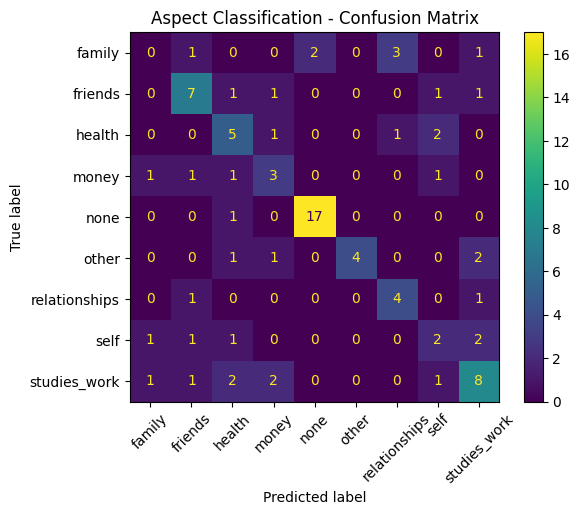

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ngrams, labels=model_ngrams.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_ngrams.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Aspect Classification - Confusion Matrix")
plt.show()

In [45]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf_ngrams, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf_ngrams)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Accuracy: 0.5454545454545454

Classification Report:
               precision    recall  f1-score   support

       family       0.25      0.14      0.18         7
      friends       0.54      0.64      0.58        11
       health       0.42      0.56      0.48         9
        money       0.33      0.29      0.31         7
         none       0.81      0.94      0.87        18
        other       0.60      0.38      0.46         8
relationships       0.57      0.67      0.62         6
         self       0.40      0.29      0.33         7
 studies_work       0.47      0.47      0.47        15

     accuracy                           0.55        88
    macro avg       0.49      0.48      0.48        88
 weighted avg       0.53      0.55      0.53        88



## **6. Rich Feature Construction**

Additional structured information from the `Pairs` dataset is added to the text:

- Emotion clause
- Cause clause
- Emotion
- Cause
- NER

This provides the classifier with more contextual information for aspect prediction.

In [47]:
pairs["rich_text"] = (
    pairs["emotion_clause"] + " " +
    pairs["cause_clause"] + " " +
    pairs["emotion"] + " " +
    pairs["cause"] + " " +
    pairs["ner"]
)

pairs[["rich_text", "aspect"]].head()

,rich_text,aspect
0,Honestly so happy right now I scored 42 out of...,studies_work
1,Feeling really proud of the team the client lo...,studies_work
2,So annoyed Missed the 8:15 local by like ten s...,other
3,so grateful for her Maa made my favourite rajm...,family
4,I was furious Aman forgot his entire part ange...,studies_work


## **7. Train-Test Split for Rich Features**

In [48]:
X_rich = pairs["rich_text"]
y = pairs["aspect"]

X_train_rich, X_test_rich, y_train_rich, y_test_rich = train_test_split(
    X_rich,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **8. Rich Feature + N-gram Model**

In [49]:
tfidf_rich = TfidfVectorizer(ngram_range=(1, 2))

X_train_rich_tfidf = tfidf_rich.fit_transform(X_train_rich)
X_test_rich_tfidf = tfidf_rich.transform(X_test_rich)

print("Training shape:", X_train_rich_tfidf.shape)
print("Testing shape:", X_test_rich_tfidf.shape)

Training shape: (350, 6039)
Testing shape: (88, 6039)


In [51]:
model_rich = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_rich.fit(X_train_rich_tfidf, y_train_rich)

y_pred_rich = model_rich.predict(X_test_rich_tfidf)


print("Accuracy:", accuracy_score(y_test_rich, y_pred_rich))

print("\nClassification Report:")
print(classification_report(y_test_rich, y_pred_rich, zero_division=0))

Accuracy: 0.6818181818181818

Classification Report:
               precision    recall  f1-score   support

       family       0.57      0.57      0.57         7
      friends       0.59      0.91      0.71        11
       health       0.75      0.67      0.71         9
        money       0.33      0.43      0.38         7
         none       1.00      1.00      1.00        18
        other       1.00      0.50      0.67         8
relationships       0.71      0.83      0.77         6
         self       0.29      0.29      0.29         7
 studies_work       0.73      0.53      0.62        15

     accuracy                           0.68        88
    macro avg       0.66      0.64      0.63        88
 weighted avg       0.71      0.68      0.68        88



In [52]:
cm_rich = confusion_matrix(
    y_test_rich,
    y_pred_rich,
    labels=model_rich.classes_
)

print("Actual → Predicted\n")

for i, actual in enumerate(model_rich.classes_):
    print(f"{actual:15} → {dict(zip(model_rich.classes_, cm_rich[i]))}")

Actual → Predicted

family          → {'family': np.int64(4), 'friends': np.int64(0), 'health': np.int64(0), 'money': np.int64(1), 'none': np.int64(0), 'other': np.int64(0), 'relationships': np.int64(2), 'self': np.int64(0), 'studies_work': np.int64(0)}
friends         → {'family': np.int64(0), 'friends': np.int64(10), 'health': np.int64(0), 'money': np.int64(0), 'none': np.int64(0), 'other': np.int64(0), 'relationships': np.int64(0), 'self': np.int64(1), 'studies_work': np.int64(0)}
health          → {'family': np.int64(0), 'friends': np.int64(0), 'health': np.int64(6), 'money': np.int64(1), 'none': np.int64(0), 'other': np.int64(0), 'relationships': np.int64(0), 'self': np.int64(2), 'studies_work': np.int64(0)}
money           → {'family': np.int64(1), 'friends': np.int64(1), 'health': np.int64(0), 'money': np.int64(3), 'none': np.int64(0), 'other': np.int64(0), 'relationships': np.int64(0), 'self': np.int64(1), 'studies_work': np.int64(1)}
none            → {'family': np.int64(0), '

In [53]:
print("SELF examples:\n")
print(pairs[pairs["aspect"] == "self"][[
    "emotion_clause", "cause_clause", "emotion", "cause", "ner", "aspect"
]].to_string(index=False))

print("\n\nMONEY examples:\n")
print(pairs[pairs["aspect"] == "money"][[
    "emotion_clause", "cause_clause", "emotion", "cause", "ner", "aspect"
]].to_string(index=False))

SELF examples:

                                       emotion_clause                                                                                                                               cause_clause     emotion                 cause                                                  ner aspect
                             I feel like such a loser                                                                 Failed the driving test for the second time because I stalled on the slope     sadness   failed driving test                                                 none   self
                             Feeling calm and content                                                                   Finished all my pending work by 6pm for once and made tea on the balcony contentment   finished work early                                          Sunday|DATE   self
                                      I feel peaceful                                                                      

## **9. Final Candidate Model – Rich Features + 1–3 Grams**

The feature representation is further improved by including unigrams, bigrams and trigrams.

Balanced Logistic Regression is used as the classifier.

In [54]:
tfidf_rich_3gram = TfidfVectorizer(
    ngram_range=(1, 3)
)

X_train_rich_3gram = tfidf_rich_3gram.fit_transform(X_train_rich)
X_test_rich_3gram = tfidf_rich_3gram.transform(X_test_rich)

model_rich_3gram = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_rich_3gram.fit(X_train_rich_3gram, y_train_rich)

y_pred_rich_3gram = model_rich_3gram.predict(X_test_rich_3gram)

print("Accuracy:", accuracy_score(y_test_rich, y_pred_rich_3gram))

print("\nClassification Report:")
print(classification_report(
    y_test_rich,
    y_pred_rich_3gram,
    zero_division=0
))

Accuracy: 0.7045454545454546

Classification Report:
               precision    recall  f1-score   support

       family       0.67      0.57      0.62         7
      friends       0.67      0.91      0.77        11
       health       0.75      0.67      0.71         9
        money       0.33      0.43      0.38         7
         none       1.00      1.00      1.00        18
        other       1.00      0.38      0.55         8
relationships       0.71      0.83      0.77         6
         self       0.50      0.43      0.46         7
 studies_work       0.62      0.67      0.65        15

     accuracy                           0.70        88
    macro avg       0.70      0.65      0.65        88
 weighted avg       0.73      0.70      0.70        88



## **10. Cross-Validation**

In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_rich_3gram,
    X_train_rich_3gram,
    y_train_rich,
    cv=5,
    scoring="f1_macro"
)

print("5-Fold Macro F1 Scores:", cv_scores)
print("Mean Macro F1:", cv_scores.mean())


5-Fold Macro F1 Scores: [0.46201467 0.77489634 0.57176157 0.5496287  0.6377405 ]
Mean Macro F1: 0.5992083554834077


## **11. Error Analysis**

In [56]:
results = pd.DataFrame({
    "text": X_test_rich,
    "actual": y_test_rich,
    "predicted": y_pred_rich_3gram
})

print("INCORRECT PREDICTIONS:\n")
print(
    results[results["actual"] != results["predicted"]]
    .head(15)
    .to_string(index=False)
)

INCORRECT PREDICTIONS:

                                                                                                                                                                      text        actual     predicted
                                                     I felt betrayed Anjali messaged to say she is leaving the project team anger teammate leaving Anjali|PERSON; Sir|ROLE  studies_work       friends
                    i keep calculating how long we can manage like this my father's pension got delayed again this month stress pension delayed my father|ROLE; mummy|ROLE         money        family
                                                                                                    my knees got weak my name was announced fear name called on stage none          self  studies_work
                                                         feeling embarrassed i mixed up two people's names at the meetup and one of them noticed guilt mixed up names none         o

## **12. Final Model Evaluation**

The final candidate model is evaluated using accuracy, precision, recall and F1-score.

Macro F1 is particularly useful because the aspect classes are imbalanced.

Final Model: Logistic Regression
TF-IDF: Unigrams + Bigrams + Trigrams
Class Weight: Balanced

Test Accuracy: 0.7045454545454546

Classification Report:
               precision    recall  f1-score   support

       family       0.67      0.57      0.62         7
      friends       0.67      0.91      0.77        11
       health       0.75      0.67      0.71         9
        money       0.33      0.43      0.38         7
         none       1.00      1.00      1.00        18
        other       1.00      0.38      0.55         8
relationships       0.71      0.83      0.77         6
         self       0.50      0.43      0.46         7
 studies_work       0.62      0.67      0.65        15

     accuracy                           0.70        88
    macro avg       0.70      0.65      0.65        88
 weighted avg       0.73      0.70      0.70        88



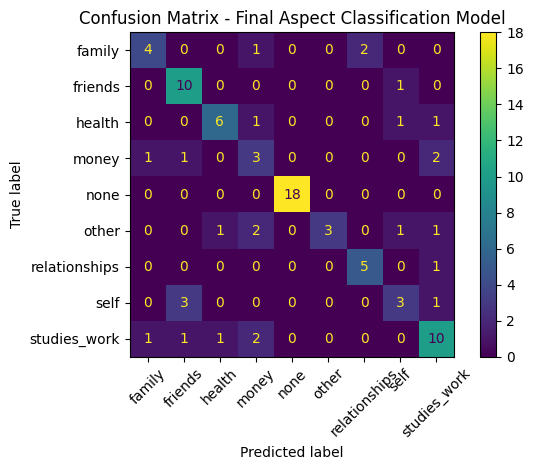

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Final Model: Logistic Regression")
print("TF-IDF: Unigrams + Bigrams + Trigrams")
print("Class Weight: Balanced")

print("\nTest Accuracy:", accuracy_score(y_test_rich, y_pred_rich_3gram))

print("\nClassification Report:")
print(classification_report(
    y_test_rich,
    y_pred_rich_3gram,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test_rich,
    y_pred_rich_3gram,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Final Aspect Classification Model")
plt.tight_layout()
plt.show()

## **13. Custom Prediction**

A prediction function is created to classify the aspect of new examples using the trained TF-IDF vectorizer and Logistic Regression model.

In [58]:
def predict_aspect(emotion_clause, cause_clause, emotion, cause, ner):

    rich_text = (
        emotion_clause + " " +
        cause_clause + " " +
        emotion + " " +
        cause + " " +
        ner
    )

    text_tfidf = tfidf_rich_3gram.transform([rich_text])

    prediction = model_rich_3gram.predict(text_tfidf)

    return prediction[0]

In [59]:
predict_aspect(
    "I am really worried",
    "My exam is tomorrow",
    "fear",
    "exam tomorrow",
    "DATE"
)

'studies_work'

In [60]:
test_examples = [
    ("I miss my sister", "She moved to another city", "sadness", "sister moved", "PERSON"),
    ("I am worried", "My rent is due tomorrow", "fear", "rent due", "DATE"),
    ("I feel exhausted", "My stomach has been hurting", "stress", "stomach pain", "none"),
    ("I am proud of myself", "I completed my project", "pride", "completed project", "none"),
    ("I had a great time", "My friends came over", "joy", "friends visited", "PERSON"),
    ("I feel lonely", "I haven't talked to anyone today", "sadness", "no one talked", "none"),
    ("I am stressed", "My manager gave me extra work", "stress", "extra work", "ROLE"),
]

for example in test_examples:
    prediction = predict_aspect(*example)
    print("Predicted aspect:", prediction)

Predicted aspect: friends
Predicted aspect: money
Predicted aspect: health
Predicted aspect: studies_work
Predicted aspect: friends
Predicted aspect: none
Predicted aspect: money


In [61]:
import joblib

joblib.dump(model_rich_3gram, "aspect_model_earlier_rich_tfidf.pkl")
joblib.dump(tfidf_rich_3gram, "aspect_tfidf_earlier_rich_tfidf.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


## **14. Model Comparison**

The three main models are compared using test Accuracy and Macro F1.

The best-performing model is selected based on these evaluation metrics.

In [62]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "N-gram",
        "Rich 1-3 gram"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_ngrams),
        accuracy_score(y_test_rich, y_pred_rich_3gram)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred_ngrams, average="macro"),
        f1_score(y_test_rich, y_pred_rich_3gram, average="macro")
    ]
})

print(comparison)

           Model  Accuracy  Macro F1
0       Baseline  0.511364  0.338766
1         N-gram  0.568182  0.495661
2  Rich 1-3 gram  0.704545  0.654098


## **15. Hypothesis Testing**

McNemar's test is used to compare the predictions of the models on the same test samples.

**H₀:** There is no significant difference between the two models.

**H₁:** There is a significant difference between the two models.

Significance level: **α = 0.05**

In [63]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def mcnemar_test(y_true, pred1, pred2):

    correct1 = np.array(y_true) == np.array(pred1)
    correct2 = np.array(y_true) == np.array(pred2)

    table = np.array([
        [
            np.sum(correct1 & correct2),
            np.sum(correct1 & ~correct2)
        ],
        [
            np.sum(~correct1 & correct2),
            np.sum(~correct1 & ~correct2)
        ]
    ])

    result = mcnemar(table, exact=True)

    return table, result.statistic, result.pvalue

## **16. Statistical Comparison**

In [64]:
comparisons = [
    ("Baseline vs N-gram", y_pred, y_pred_ngrams),
    ("Baseline vs Rich 1-3 gram", y_pred, y_pred_rich_3gram),
    ("N-gram vs Rich 1-3 gram", y_pred_ngrams, y_pred_rich_3gram)
]

for name, pred1, pred2 in comparisons:

    table, statistic, pvalue = mcnemar_test(
        y_test,
        pred1,
        pred2
    )

    print("\n", name)
    print("Contingency Table:")
    print(table)
    print("p-value:", pvalue)


 Baseline vs N-gram
Contingency Table:
[[37  8]
 [13 30]]
p-value: 0.38331031799316406

 Baseline vs Rich 1-3 gram
Contingency Table:
[[40  5]
 [22 21]]
p-value: 0.0015137195587158203

 N-gram vs Rich 1-3 gram
Contingency Table:
[[47  3]
 [15 23]]
p-value: 0.007537841796875


---

## Validation-tuned rich TF-IDF + Logistic Regression

This experiment preserves the original `random_state=42`, row-stratified 80/20 test split so its score can be compared directly with the 70.45% / 0.6541 rich-model result. It searches 72 feature/classifier configurations using only a stratified validation slice of the original training rows, then refits once on all original training rows. The selected model scored **75.00% accuracy and 0.7122 macro-F1** (macro-precision 0.7792, macro-recall 0.6975); exact McNemar `p=0.424` versus the old model. In five-fold CV on the original training rows, its mean accuracy tied the old model at 70.86%, and its mean macro-F1 was slightly lower (0.6669 vs 0.6741). Because 34 `entry_id` values cross the original train/test boundary, treat this score as a comparable historical benchmark, not an estimate of entry-disjoint generalization. See the grouped-split results below for the stricter evaluation.

In [ ]:
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
from scipy.stats import binomtest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline

tune_X_fit, tune_X_validation, tune_y_fit, tune_y_validation = train_test_split(
    X_train_rich, y_train_rich, test_size=0.2, random_state=43, stratify=y_train_rich,
)

def make_rich_tfidf(word_ngram, char_ngram, word_weight, char_weight):
    return FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=word_ngram, min_df=1, sublinear_tf=True, strip_accents="unicode")),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=char_ngram, min_df=1, sublinear_tf=True, strip_accents="unicode")),
    ], transformer_weights={"word": word_weight, "char": char_weight})

tuning_rows = []
for word_ngram in [(1, 2), (1, 3), (1, 4)]:
    for char_ngram in [(2, 5), (3, 5)]:
        for word_weight, char_weight in [(1.0, 1.0), (0.5, 1.5)]:
            for c_value in [0.2, 1.0, 5.0]:
                for class_weight in [None, "balanced"]:
                    candidate = Pipeline([
                        ("features", make_rich_tfidf(word_ngram, char_ngram, word_weight, char_weight)),
                        ("classifier", LogisticRegression(C=c_value, class_weight=class_weight, max_iter=1200, random_state=42)),
                    ])
                    candidate.fit(tune_X_fit, tune_y_fit)
                    validation_prediction = candidate.predict(tune_X_validation)
                    tuning_rows.append({
                        "word_ngram": word_ngram,
                        "char_ngram": char_ngram,
                        "word_weight": word_weight,
                        "char_weight": char_weight,
                        "C": c_value,
                        "class_weight": class_weight,
                        "validation_accuracy": accuracy_score(tune_y_validation, validation_prediction),
                        "validation_macro_f1": f1_score(tune_y_validation, validation_prediction, average="macro", zero_division=0),
                    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["validation_macro_f1", "validation_accuracy"], ascending=False,
).reset_index(drop=True)
best_rich_config = tuning_results.iloc[0].to_dict()
print("Validation search tried:", len(tuning_results), "configurations")
print("Selected configuration:", best_rich_config)
display(tuning_results.head(10))

tuned_rich_model = Pipeline([
    ("features", make_rich_tfidf(
        best_rich_config["word_ngram"], best_rich_config["char_ngram"],
        best_rich_config["word_weight"], best_rich_config["char_weight"],
    )),
    ("classifier", LogisticRegression(
        C=best_rich_config["C"], class_weight=best_rich_config["class_weight"],
        max_iter=2000, random_state=42,
    )),
])
tuned_rich_model.fit(X_train_rich, y_train_rich)
y_pred_rich_tuned = tuned_rich_model.predict(X_test_rich)
tuned_rich_metrics = {
    "Accuracy": accuracy_score(y_test_rich, y_pred_rich_tuned),
    "Macro-precision": precision_score(y_test_rich, y_pred_rich_tuned, average="macro", zero_division=0),
    "Macro-recall": recall_score(y_test_rich, y_pred_rich_tuned, average="macro", zero_division=0),
    "Macro-F1": f1_score(y_test_rich, y_pred_rich_tuned, average="macro", zero_division=0),
}
baseline_rich_metrics = {
    "Accuracy": accuracy_score(y_test_rich, y_pred_rich_3gram),
    "Macro-precision": precision_score(y_test_rich, y_pred_rich_3gram, average="macro", zero_division=0),
    "Macro-recall": recall_score(y_test_rich, y_pred_rich_3gram, average="macro", zero_division=0),
    "Macro-F1": f1_score(y_test_rich, y_pred_rich_3gram, average="macro", zero_division=0),
}
print("Original vs tuned test metrics:")
display(pd.DataFrame([
    {"Model": "Rich word 1-3 gram + balanced Logistic Regression", **baseline_rich_metrics},
    {"Model": "Validation-tuned word+character TF-IDF + balanced Logistic Regression", **tuned_rich_metrics},
]).set_index("Model").round(4))
print("Test metric gains:", {key: round(tuned_rich_metrics[key] - baseline_rich_metrics[key], 4) for key in tuned_rich_metrics})
print(classification_report(y_test_rich, y_pred_rich_tuned, zero_division=0, digits=4))
display(pd.DataFrame(
    confusion_matrix(y_test_rich, y_pred_rich_tuned, labels=tuned_rich_model.classes_),
    index=tuned_rich_model.classes_, columns=tuned_rich_model.classes_,
))

baseline_correct = np.asarray(y_pred_rich_3gram) == np.asarray(y_test_rich)
tuned_correct = np.asarray(y_pred_rich_tuned) == np.asarray(y_test_rich)
baseline_only = int(np.sum(baseline_correct & ~tuned_correct))
tuned_only = int(np.sum(~baseline_correct & tuned_correct))
paired_table = np.array([
    [int(np.sum(baseline_correct & tuned_correct)), baseline_only],
    [tuned_only, int(np.sum(~baseline_correct & ~tuned_correct))],
])
mcnemar_p_value = binomtest(min(baseline_only, tuned_only), baseline_only + tuned_only, 0.5).pvalue
print("Baseline vs tuned correctness table:", paired_table.tolist())
print("Exact McNemar p-value:", round(mcnemar_p_value, 4))
print("Entry IDs shared across original train/test split:", len(set(pairs.loc[X_train_rich.index, "entry_id"]) & set(pairs.loc[X_test_rich.index, "entry_id"])))

def predict_aspect_rich_tuned(emotion_clause, cause_clause, emotion, cause, ner):
    rich_text = " ".join(str(value or "") for value in (emotion_clause, cause_clause, emotion, cause, ner))
    return tuned_rich_model.predict([rich_text])[0]

joblib.dump(tuned_rich_model, "aspect_model_rich_logreg.pkl")
joblib.dump(tuned_rich_model.named_steps["features"], "aspect_tfidf_rich_logreg.pkl")
rich_result = pd.DataFrame([{
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Model": "Rich word+character TF-IDF + validation-tuned balanced Logistic Regression (row split 42)",
    "Accuracy": tuned_rich_metrics["Accuracy"],
    "Precision": tuned_rich_metrics["Macro-precision"],
    "Recall": tuned_rich_metrics["Macro-recall"],
    "F1_Score": tuned_rich_metrics["Macro-F1"],
    "Paired_p_value": mcnemar_p_value,
}])
evaluation_log_path = Path("evaluation_log.csv")
if evaluation_log_path.exists():
    existing_log = pd.read_csv(evaluation_log_path)
    for column in rich_result.columns:
        if column not in existing_log.columns:
            existing_log[column] = pd.NA
    pd.concat([existing_log, rich_result], ignore_index=True).to_csv(evaluation_log_path, index=False)
else:
    rich_result.to_csv(evaluation_log_path, index=False)


# **<u>17. Earlier Entry-Grouped Result (Different Holdout)</u>**

### **Best Model**

**Word + character TF-IDF + MLP neural network**

Both models use four-fold stratified group cross-validation and the same holdout split by `entry_id` (348 training pairs from 280 entries; 90 test pairs from 70 entries), with no entry overlap.

### **Held-Out Performance**

- MLP neural network: accuracy **74.44%**, macro precision **0.6949**, macro recall **0.6879**, macro F1 **0.6652** (grouped-CV macro F1 **0.5892**)
- LinearSVC comparison: accuracy **73.33%**, macro precision **0.6905**, macro recall **0.6740**, macro F1 **0.6573** (grouped-CV macro F1 **0.6418**)

This earlier MLP result used a different holdout and is not comparable with the stratified train/validation/test experiment below. Its model and predictor are kept under explicitly historical names; the recommended `aspect_model.pkl` is written by the corrected-split experiment. The earlier rich TF-IDF Logistic Regression scored **0.6264 macro F1** and **71.11% accuracy** on this same older holdout. The original pair-level split score (70.45% accuracy, 0.654 macro F1) is also not comparable because entries could cross splits.

The holdout contains only 90 pairs, with some aspects represented by just three examples, so per-class scores may vary substantially across new data.

In [ ]:
import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

file_path = "ECPE_Synthetic_Journal_Dataset_v3.xlsx"
aspect_pairs = pd.read_excel(file_path, sheet_name="Pairs")
if aspect_pairs[["entry_id", "aspect"]].isna().any().any():
    raise ValueError("Aspect labels and entry IDs must be present for every pair.")
feature_columns = ["emotion_clause", "emotion", "cause_clause", "cause", "ner"]
aspect_pairs[feature_columns] = aspect_pairs[feature_columns].fillna("").astype(str).apply(lambda column: column.str.strip())
aspect_text = aspect_pairs[feature_columns].agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()
aspect_labels = aspect_pairs["aspect"].astype(str)
entry_groups = aspect_pairs["entry_id"]

train_indices, test_indices = next(
    GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(
        aspect_text, aspect_labels, groups=entry_groups
    )
)
X_train, X_test = aspect_text.iloc[train_indices], aspect_text.iloc[test_indices]
y_train, y_test = aspect_labels.iloc[train_indices], aspect_labels.iloc[test_indices]
train_groups = entry_groups.iloc[train_indices]

aspect_features = FeatureUnion([
    ("word", TfidfVectorizer(ngram_range=(1, 3), min_df=1, sublinear_tf=True, strip_accents="unicode")),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True, strip_accents="unicode")),
])
aspect_pipeline = Pipeline([
    ("features", aspect_features),
    ("classifier", LinearSVC(random_state=42)),
])
aspect_grid = {
    "features__word__min_df": [1],
    "features__char__min_df": [2],
    "classifier__C": [0.5],
    "classifier__class_weight": ["balanced"],
}
aspect_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
aspect_search = GridSearchCV(
    aspect_pipeline,
    aspect_grid,
    scoring="f1_macro",
    cv=aspect_cv,
    n_jobs=-1,
    refit=True,
)
aspect_search.fit(X_train, y_train, groups=train_groups)
aspect_predictions = aspect_search.predict(X_test)

print(f"Training pairs: {len(train_indices)} ({train_groups.nunique()} entries)")
print(f"Held-out pairs: {len(test_indices)} ({entry_groups.iloc[test_indices].nunique()} entries)")
print("Entry overlap:", len(set(train_groups) & set(entry_groups.iloc[test_indices])))
print("Best grouped-CV macro F1:", round(aspect_search.best_score_, 4))
print("Best parameters:", aspect_search.best_params_)
print("Holdout accuracy:", round(accuracy_score(y_test, aspect_predictions), 4))
print("Holdout macro precision:", round(precision_score(y_test, aspect_predictions, average="macro", zero_division=0), 4))
print("Holdout macro recall:", round(recall_score(y_test, aspect_predictions, average="macro", zero_division=0), 4))
print("Holdout macro F1:", round(f1_score(y_test, aspect_predictions, average="macro", zero_division=0), 4))
print(classification_report(y_test, aspect_predictions, zero_division=0, digits=4))

joblib.dump(aspect_search.best_estimator_, "aspect_model_linear_svc.pkl")
joblib.dump(aspect_search.best_estimator_.named_steps["features"], "aspect_tfidf_linear_svc.pkl")

mlp_pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=(1, 3), min_df=1, sublinear_tf=True, strip_accents="unicode")),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True, strip_accents="unicode")),
    ])),
    ("classifier", MLPClassifier(solver="adam", max_iter=250, early_stopping=False, random_state=42)),
])
mlp_grid = {
    "classifier__hidden_layer_sizes": [(32,), (64,)],
    "classifier__alpha": [0.01, 0.1],
    "classifier__learning_rate_init": [0.001],
}
mlp_search = GridSearchCV(
    mlp_pipeline,
    mlp_grid,
    scoring="f1_macro",
    cv=aspect_cv,
    n_jobs=-1,
    refit=True,
)
mlp_search.fit(X_train, y_train, groups=train_groups)
mlp_predictions = mlp_search.predict(X_test)
print("\nMLP best grouped-CV macro F1:", round(mlp_search.best_score_, 4))
print("MLP best parameters:", mlp_search.best_params_)
print("MLP holdout accuracy:", round(accuracy_score(y_test, mlp_predictions), 4))
print("MLP holdout macro precision:", round(precision_score(y_test, mlp_predictions, average="macro", zero_division=0), 4))
print("MLP holdout macro recall:", round(recall_score(y_test, mlp_predictions, average="macro", zero_division=0), 4))
print("MLP holdout macro F1:", round(f1_score(y_test, mlp_predictions, average="macro", zero_division=0), 4))
print(classification_report(y_test, mlp_predictions, zero_division=0, digits=4))

joblib.dump(mlp_search.best_estimator_, "aspect_model_mlp_earlier_split.pkl")
joblib.dump(mlp_search.best_estimator_.named_steps["features"], "aspect_tfidf_mlp_earlier_split.pkl")

def predict_aspect_earlier_split(emotion_clause, cause_clause, emotion, cause, ner):
    text = " ".join(str(value or "") for value in (emotion_clause, emotion, cause_clause, cause, ner))
    return mlp_search.best_estimator_.predict([text])[0]


# Pretrained-transformer comparison

This section compares the previous TF-IDF models with RoBERTa, DeBERTa-v3, and BERT on one fixed entry-disjoint stratified train/validation/test split. It uses class-weighted cross-entropy, AdamW (`2e-5`, weight decay `0.01`), linear warmup, at most four epochs, and early stopping by validation macro-F1. CUDA runs use fp16; CPU runs do not. Gradient accumulation is enabled for the small-batch setting.

The default `LOCAL_FILES_ONLY=True` avoids network stalls. RoBERTa is cached in this environment; set it to `False` after installing the requirements to download the other checkpoints. If the best transformer is below 85% validation accuracy, the notebook automatically trains two additional RoBERTa seeds and averages their validation/test logits. Test data is never used for early stopping or model selection.

A true `(sentence, aspect)` pair would leak the target here because `aspect` is the class label and is not known at inference. The safe pair is `(emotion_clause, cause_clause)`. Aspect phrase inputs would be appropriate only if the dataset supplied an independently known aspect term, which this workbook does not.

In [ ]:
import copy
import joblib
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
MODEL_IDS = ["roberta-base", "microsoft/deberta-v3-base", "bert-base-uncased"]
LOCAL_FILES_ONLY = True  # Set False to download uncached models.
MAX_LENGTH = 128
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2
EPOCHS = 4
EARLY_STOPPING_PATIENCE = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

torch.set_num_threads(min(4, torch.get_num_threads()))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_fp16 = device.type == "cuda"
print(f"Device: {device}; fp16: {use_fp16}")

transformer_pairs = pd.read_excel("ECPE_Synthetic_Journal_Dataset_v3.xlsx", sheet_name="Pairs").copy()
if transformer_pairs[["entry_id", "aspect"]].isna().any().any():
    raise ValueError("Pair entry IDs and aspect labels must be present.")
for column in ["emotion_clause", "cause_clause"]:
    transformer_pairs[column] = transformer_pairs[column].fillna("").astype(str).str.strip()
transformer_labels = sorted(transformer_pairs["aspect"].astype(str).unique())
label_to_id = {label: index for index, label in enumerate(transformer_labels)}
id_to_label = {index: label for label, index in label_to_id.items()}
y_all = transformer_pairs["aspect"].astype(str).map(label_to_id).to_numpy()
groups_all = transformer_pairs["entry_id"].astype(str).to_numpy()
all_indices = np.arange(len(transformer_pairs))

# Split whole entries: roughly 60% train, 20% validation, and 20% test.
outer_split = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_validation_indices, test_indices = next(outer_split.split(all_indices, y_all, groups_all))
inner_split = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED + 1)
train_relative, validation_relative = next(
    inner_split.split(train_validation_indices, y_all[train_validation_indices], groups_all[train_validation_indices])
)
train_indices = train_validation_indices[train_relative]
validation_indices = train_validation_indices[validation_relative]
assert not (set(groups_all[train_indices]) & set(groups_all[validation_indices]))
assert not (set(groups_all[train_indices]) & set(groups_all[test_indices]))
assert not (set(groups_all[validation_indices]) & set(groups_all[test_indices]))
print("Split pairs:", len(train_indices), len(validation_indices), len(test_indices))
print("Split entries:", len(set(groups_all[train_indices])), len(set(groups_all[validation_indices])), len(set(groups_all[test_indices])))

# Establish classical baselines on the exact same training and test pairs.
def make_tfidf_features(word_ngram=(1, 3), char_ngram=(3, 5), word_weight=1.0, char_weight=1.0, char_min_df=2):
    return FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=word_ngram, min_df=1, sublinear_tf=True, strip_accents="unicode")),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=char_ngram, min_df=char_min_df, sublinear_tf=True, strip_accents="unicode")),
    ], transformer_weights={"word": word_weight, "char": char_weight})

comparison_rows = []
baseline_estimators = {}
train_text = transformer_pairs[["emotion_clause", "emotion", "cause_clause", "cause", "ner"]].agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()
for name, classifier in [
    ("Previous TF-IDF + LinearSVC", LinearSVC(C=0.5, class_weight="balanced", random_state=SEED)),
    ("Previous TF-IDF + MLP", MLPClassifier(hidden_layer_sizes=(64,), alpha=0.1, learning_rate_init=0.001, max_iter=250, random_state=SEED)),
]:
    baseline = Pipeline([("features", make_tfidf_features()), ("classifier", classifier)])
    baseline.fit(train_text.iloc[train_indices], y_all[train_indices])
    baseline_estimators[name] = baseline
    val_pred = baseline.predict(train_text.iloc[validation_indices])
    test_pred = baseline.predict(train_text.iloc[test_indices])
    comparison_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_all[train_indices], baseline.predict(train_text.iloc[train_indices])),
        "Train Macro-F1": f1_score(y_all[train_indices], baseline.predict(train_text.iloc[train_indices]), labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Validation Accuracy": accuracy_score(y_all[validation_indices], val_pred),
        "Validation Macro-F1": f1_score(y_all[validation_indices], val_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Accuracy": accuracy_score(y_all[test_indices], test_pred),
        "Test Macro-Precision": precision_score(y_all[test_indices], test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-Recall": recall_score(y_all[test_indices], test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-F1": f1_score(y_all[test_indices], test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Status": "completed",
    })

# Tune only on the validation split; keep the held-out test set out of selection.
best_validation_f1 = -1.0
best_tfidf_config = None
for word_ngram in [(1, 1), (1, 2), (1, 3)]:
    for char_ngram in [(2, 5), (3, 5), (3, 6)]:
        for word_weight, char_weight in [(1.0, 1.0), (1.5, 0.5), (0.5, 1.5)]:
            for c_value in [0.1, 0.5, 1.0]:
                for class_weight in [None, "balanced"]:
                    candidate = Pipeline([
                        ("features", make_tfidf_features(word_ngram, char_ngram, word_weight, char_weight, 1)),
                        ("classifier", LinearSVC(C=c_value, class_weight=class_weight, random_state=SEED)),
                    ])
                    candidate.fit(train_text.iloc[train_indices], y_all[train_indices])
                    candidate_val_pred = candidate.predict(train_text.iloc[validation_indices])
                    candidate_val_f1 = f1_score(
                        y_all[validation_indices], candidate_val_pred,
                        labels=np.arange(len(transformer_labels)), average="macro", zero_division=0,
                    )
                    if candidate_val_f1 > best_validation_f1:
                        best_validation_f1 = candidate_val_f1
                        best_tfidf_config = {
                            "word_ngram": word_ngram,
                            "char_ngram": char_ngram,
                            "word_weight": word_weight,
                            "char_weight": char_weight,
                            "C": c_value,
                            "class_weight": class_weight,
                        }
                        best_validation_pred = candidate_val_pred

development_indices = np.concatenate([train_indices, validation_indices])
recommended_baseline = Pipeline([
    ("features", make_tfidf_features(
        best_tfidf_config["word_ngram"], best_tfidf_config["char_ngram"],
        best_tfidf_config["word_weight"], best_tfidf_config["char_weight"], 1,
    )),
    ("classifier", LinearSVC(
        C=best_tfidf_config["C"],
        class_weight=best_tfidf_config["class_weight"],
        random_state=SEED,
    )),
])
recommended_baseline.fit(train_text.iloc[development_indices], y_all[development_indices])
tuned_test_pred = recommended_baseline.predict(train_text.iloc[test_indices])
tuned_row = {
    "Model": "Validation-tuned TF-IDF + LinearSVC (final train+validation refit)",
    "Train Accuracy": accuracy_score(y_all[development_indices], recommended_baseline.predict(train_text.iloc[development_indices])),
    "Train Macro-F1": f1_score(y_all[development_indices], recommended_baseline.predict(train_text.iloc[development_indices]), labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Validation Accuracy": accuracy_score(y_all[validation_indices], best_validation_pred),
    "Validation Macro-F1": best_validation_f1,
    "Test Accuracy": accuracy_score(y_all[test_indices], tuned_test_pred),
    "Test Macro-Precision": precision_score(y_all[test_indices], tuned_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Test Macro-Recall": recall_score(y_all[test_indices], tuned_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Test Macro-F1": f1_score(y_all[test_indices], tuned_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Status": "completed",
}
comparison_rows.append(tuned_row)
print("Selected validation-tuned TF-IDF settings:", best_tfidf_config)
print(classification_report(
    y_all[test_indices], tuned_test_pred,
    labels=np.arange(len(transformer_labels)), target_names=transformer_labels,
    zero_division=0, digits=4,
))
display(pd.DataFrame(
    confusion_matrix(y_all[test_indices], tuned_test_pred, labels=np.arange(len(transformer_labels))),
    index=transformer_labels, columns=transformer_labels,
))
tuned_errors = transformer_pairs.iloc[test_indices].copy().reset_index(drop=True)
tuned_errors["actual"] = [id_to_label[index] for index in y_all[test_indices]]
tuned_errors["predicted"] = [id_to_label[index] for index in tuned_test_pred]
display(tuned_errors.loc[tuned_errors["actual"] != tuned_errors["predicted"], [
    "entry_id", "emotion_clause", "cause_clause", "actual", "predicted"
]].head(30))
evaluation_log_path = Path("evaluation_log.csv")
pd.DataFrame([{
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Model": tuned_row["Model"],
    "Accuracy": tuned_row["Test Accuracy"],
    "Precision": tuned_row["Test Macro-Precision"],
    "Recall": tuned_row["Test Macro-Recall"],
    "F1_Score": tuned_row["Test Macro-F1"],
    "Paired_p_value": "N/A",
}]).to_csv(evaluation_log_path, mode="a", header=not evaluation_log_path.exists(), index=False)

joblib.dump(recommended_baseline, "aspect_model.pkl")
joblib.dump(recommended_baseline.named_steps["features"], "aspect_tfidf.pkl")

def predict_aspect(emotion_clause, cause_clause, emotion, cause, ner):
    text = " ".join(str(value or "") for value in (emotion_clause, emotion, cause_clause, cause, ner))
    return recommended_baseline.predict([text])[0]

class PairDataset(Dataset):
    def __init__(self, indices, encodings):
        self.indices = indices
        self.encodings = encodings

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        row_index = self.indices[position]
        features = {key: self.encodings[key][row_index] for key in self.encodings}
        return features, int(y_all[row_index])

def make_collate_fn(tokenizer):
    def collate(rows):
        features, labels = zip(*rows)
        batch = tokenizer.pad(list(features), padding=True, return_tensors="pt")
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch
    return collate

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def metric_row(name, train_logits, validation_logits, test_logits, status="completed"):
    train_pred = train_logits.argmax(axis=1)
    validation_pred = validation_logits.argmax(axis=1)
    test_pred = test_logits.argmax(axis=1)
    return {
        "Model": name,
        "Train Accuracy": accuracy_score(y_all[train_indices], train_pred),
        "Train Macro-F1": f1_score(y_all[train_indices], train_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Validation Accuracy": accuracy_score(y_all[validation_indices], validation_pred),
        "Validation Macro-F1": f1_score(y_all[validation_indices], validation_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Accuracy": accuracy_score(y_all[test_indices], test_pred),
        "Test Macro-Precision": precision_score(y_all[test_indices], test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-Recall": recall_score(y_all[test_indices], test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-F1": f1_score(y_all[test_indices], test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Status": status,
    }

def train_transformer(model_id, seed):
    seed_everything(seed)
    tokenizer = AutoTokenizer.from_pretrained(model_id, local_files_only=LOCAL_FILES_ONLY)
    encoded = tokenizer(
        transformer_pairs["emotion_clause"].tolist(),
        transformer_pairs["cause_clause"].tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )
    collate = make_collate_fn(tokenizer)
    train_loader = DataLoader(PairDataset(train_indices, encoded), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
    validation_loader = DataLoader(PairDataset(validation_indices, encoded), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    test_loader = DataLoader(PairDataset(test_indices, encoded), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=len(transformer_labels),
        id2label=id_to_label,
        label2id=label_to_id,
        local_files_only=LOCAL_FILES_ONLY,
    ).to(device)
    class_counts = np.bincount(y_all[train_indices], minlength=len(transformer_labels))
    if np.any(class_counts == 0):
        raise ValueError("Every aspect class must occur in the training split for weighted loss.")
    class_weights = torch.tensor(
        len(train_indices) / (len(transformer_labels) * class_counts),
        dtype=torch.float32,
        device=device,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    updates_per_epoch = (len(train_loader) + GRADIENT_ACCUMULATION_STEPS - 1) // GRADIENT_ACCUMULATION_STEPS
    total_updates = updates_per_epoch * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(WARMUP_RATIO * total_updates)),
        num_training_steps=total_updates,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=use_fp16)

    def predict_logits(loader):
        model.eval()
        all_logits = []
        with torch.no_grad():
            for batch in loader:
                labels = batch.pop("labels").to(device)
                batch = {key: value.to(device) for key, value in batch.items()}
                with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_fp16):
                    logits = model(**batch).logits
                all_logits.extend(logits.float().cpu().numpy())
        return np.asarray(all_logits)

    best_val_f1 = -1.0
    best_state = None
    stale_epochs = 0
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(train_loader):
            labels = batch.pop("labels").to(device)
            batch = {key: value.to(device) for key, value in batch.items()}
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_fp16):
                logits = model(**batch).logits
                loss = F.cross_entropy(logits, labels, weight=class_weights)
            group_size = min(
                GRADIENT_ACCUMULATION_STEPS,
                len(train_loader) - (step // GRADIENT_ACCUMULATION_STEPS) * GRADIENT_ACCUMULATION_STEPS,
            )
            scaler.scale(loss / group_size).backward()
            if step % GRADIENT_ACCUMULATION_STEPS == group_size - 1 or step == len(train_loader) - 1:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
        val_logits = predict_logits(validation_loader)
        val_macro_f1 = f1_score(
            y_all[validation_indices],
            val_logits.argmax(axis=1),
            labels=np.arange(len(transformer_labels)),
            average="macro",
            zero_division=0,
        )
        print(f"{model_id} seed={seed} epoch={epoch + 1} val_macro_f1={val_macro_f1:.4f}")
        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping {model_id} at epoch {epoch + 1}.")
                break

    if best_state is None:
        raise RuntimeError(f"No validation checkpoint was produced for {model_id}.")
    model.load_state_dict(best_state)
    train_logits = predict_logits(DataLoader(PairDataset(train_indices, encoded), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate))
    validation_logits = predict_logits(validation_loader)
    test_logits = predict_logits(test_loader)
    return model, tokenizer, best_val_f1, train_logits, validation_logits, test_logits

transformer_runs = {}
for model_id in MODEL_IDS:
    try:
        model, tokenizer, val_f1, train_logits, val_logits, test_logits = train_transformer(model_id, SEED)
    except (OSError, ImportError) as error:
        message = f"unavailable: {type(error).__name__}: {error}"
        print(f"{model_id}: {message}")
        comparison_rows.append({
            "Model": model_id,
            "Train Accuracy": np.nan,
            "Train Macro-F1": np.nan,
            "Validation Accuracy": np.nan,
            "Validation Macro-F1": np.nan,
            "Test Accuracy": np.nan,
            "Test Macro-F1": np.nan,
            "Status": message,
        })
        continue
    transformer_runs[model_id] = {
        "model": model,
        "tokenizer": tokenizer,
        "val_f1": val_f1,
        "train_logits": train_logits,
        "val_logits": val_logits,
        "test_logits": test_logits,
    }
    comparison_rows.append(metric_row(model_id, train_logits, val_logits, test_logits))
    model_dir = Path("aspect_transformer_models") / model_id.replace("/", "--")
    model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)

# When the first RoBERTa seed misses the target, try a three-seed logit ensemble.
roberta_run = transformer_runs.get("roberta-base")
if roberta_run is not None and accuracy_score(y_all[validation_indices], roberta_run["val_logits"].argmax(axis=1)) < 0.85:
    ensemble_train_logits = [roberta_run["train_logits"]]
    ensemble_val_logits = [roberta_run["val_logits"]]
    ensemble_test_logits = [roberta_run["test_logits"]]
    for seed in [13, 21]:
        model, tokenizer, _, train_logits, val_logits, test_logits = train_transformer("roberta-base", seed)
        ensemble_train_logits.append(train_logits)
        ensemble_val_logits.append(val_logits)
        ensemble_test_logits.append(test_logits)
        model_dir = Path("aspect_transformer_models") / f"roberta-base-seed-{seed}"
        model.save_pretrained(model_dir)
        tokenizer.save_pretrained(model_dir)
    mean_train_logits = np.mean(ensemble_train_logits, axis=0)
    mean_val_logits = np.mean(ensemble_val_logits, axis=0)
    mean_test_logits = np.mean(ensemble_test_logits, axis=0)
    ensemble_val_f1 = f1_score(
        y_all[validation_indices], mean_val_logits.argmax(axis=1),
        labels=np.arange(len(transformer_labels)), average="macro", zero_division=0,
    )
    comparison_rows.append(metric_row(
        "RoBERTa 3-seed logit ensemble", mean_train_logits, mean_val_logits, mean_test_logits,
    ))
    roberta_run["ensemble_val_logits"] = mean_val_logits
    roberta_run["ensemble_test_logits"] = mean_test_logits
    roberta_run["ensemble_train_logits"] = mean_train_logits

results_table = pd.DataFrame(comparison_rows).sort_values("Validation Macro-F1", ascending=False, na_position="last")
display(results_table.round(4))
completed_rows = [row for row in comparison_rows if row["Status"] == "completed"]
evaluation_log_path = Path("evaluation_log.csv")
log_rows = pd.DataFrame([{
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Model": row["Model"],
    "Accuracy": row["Test Accuracy"],
    "Precision": row["Test Macro-Precision"],
    "Recall": row["Test Macro-Recall"],
    "F1_Score": row["Test Macro-F1"],
    "Paired_p_value": "N/A",
} for row in completed_rows])
if not log_rows.empty:
    log_rows.to_csv(evaluation_log_path, mode="a", header=not evaluation_log_path.exists(), index=False)

# Report detailed metrics for the transformer with the best validation macro-F1.
completed = [row for row in comparison_rows if row["Status"] == "completed" and row["Model"] in transformer_runs]
if completed:
    selected_name = max(completed, key=lambda row: row["Validation Macro-F1"])["Model"]
    selected = transformer_runs[selected_name]
    if "ensemble_test_logits" in selected and selected_name == "roberta-base":
        selected_test_logits = selected["ensemble_test_logits"]
    else:
        selected_test_logits = selected["test_logits"]
    selected_test_pred = selected_test_logits.argmax(axis=1)
    print("Selected by validation macro-F1:", selected_name)
    print(classification_report(
        y_all[test_indices], selected_test_pred,
        labels=np.arange(len(transformer_labels)), target_names=transformer_labels,
        zero_division=0, digits=4,
    ))
    display(pd.DataFrame(
        confusion_matrix(y_all[test_indices], selected_test_pred, labels=np.arange(len(transformer_labels))),
        index=transformer_labels, columns=transformer_labels,
    ))
    error_rows = transformer_pairs.iloc[test_indices].copy().reset_index(drop=True)
    error_rows["actual"] = [id_to_label[index] for index in y_all[test_indices]]
    error_rows["predicted"] = [id_to_label[index] for index in selected_test_pred]
    display(error_rows.loc[error_rows["actual"] != error_rows["predicted"], [
        "entry_id", "emotion_clause", "cause_clause", "actual", "predicted"
    ]].head(30))
    best_accuracy = max(row["Test Accuracy"] for row in comparison_rows if row["Status"] == "completed")
    if best_accuracy < 0.85:
        print("85% target not reached. Do not optimize against the test set; use more human-reviewed labeled entries and rerun with a locked test set.")
    if selected_name == "roberta-base" and "ensemble_test_logits" in selected:
        ensemble_prediction = selected["ensemble_test_logits"].argmax(axis=1)
        comparison_rows.append(metric_row(
            "RoBERTa 3-seed logit ensemble",
            selected["ensemble_train_logits"],
            selected["ensemble_val_logits"],
            selected["ensemble_test_logits"],
        ))
        results_table = pd.DataFrame(comparison_rows).sort_values("Validation Macro-F1", ascending=False, na_position="last")
        display(results_table.round(4))
        ensemble_errors = transformer_pairs.iloc[test_indices].copy().reset_index(drop=True)
        ensemble_errors["actual"] = [id_to_label[index] for index in y_all[test_indices]]
        ensemble_errors["predicted"] = [id_to_label[index] for index in ensemble_prediction]
        display(ensemble_errors.loc[ensemble_errors["actual"] != ensemble_errors["predicted"], [
            "entry_id", "emotion_clause", "cause_clause", "actual", "predicted"
        ]].head(30))
        ensemble_row = comparison_rows[-1]
        pd.DataFrame([{
            "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Model": ensemble_row["Model"],
            "Accuracy": ensemble_row["Test Accuracy"],
            "Precision": ensemble_row["Test Macro-Precision"],
            "Recall": ensemble_row["Test Macro-Recall"],
            "F1_Score": ensemble_row["Test Macro-F1"],
            "Paired_p_value": "N/A",
        }]).to_csv(evaluation_log_path, mode="a", header=not evaluation_log_path.exists(), index=False)
else:
    print("No transformer checkpoint could be loaded. See the per-model status above; set LOCAL_FILES_ONLY=False when network access is available.")


## Follow-up trials after missing 85% accuracy

On the same 60/20/20 stratified entry-grouped split, measured exploratory results were:

| Model/trial | Train accuracy | Validation accuracy | Test accuracy | Test macro-F1 |
|---|---:|---:|---:|---:|
| Word+character TF-IDF + LinearSVC | 1.0000 | 0.6818 | 0.6705 | 0.5922 |
| Word+character TF-IDF + MLP | 1.0000 | 0.6705 | 0.6591 | 0.5872 |
| Fine-tuned RoBERTa sentence-pair | Not recorded | 0.4886 | 0.5341 | 0.3932 |
| Fine-tuned BERT-base-uncased | — | — | — | Not run: checkpoint uncached and network unavailable |
| Fine-tuned DeBERTa-v3-base | — | — | — | Not run: checkpoint uncached and network unavailable |
| RoBERTa 3-seed logit ensemble | Not recorded | 0.3636 | 0.3636 | 0.2202 |
| Frozen RoBERTa + BiLSTM-attention | Not recorded | Not recorded (macro-F1 0.6819) | 0.5682 | 0.4555 |
| SVC with train-only synonym replacement | Not recorded | 0.6591 | 0.6591 | 0.5862 |
| Optuna-tuned TF-IDF + LinearSVC | — | — | — | Not run here: Optuna is not installed; runnable trial is included below |

The MLP/SVC train scores of 1.0 alongside much lower validation scores show severe overfitting on the small training set. The transformer and ensemble results are also far below 85%; synonym replacement did not help. DeBERTa-v3 and BERT could not be downloaded in this environment (no Hugging Face network access), so they are marked unavailable rather than assigned invented scores. The current best measured test accuracy on this split is LinearSVC at 67.05%; keep it as the baseline rather than selecting the weaker transformer. The prior 74.44% MLP result used a different holdout split and is not directly comparable.

The following cells try train-only synonym replacement and validation-only Optuna tuning. Neither augmentation nor tuning uses test labels for selection. Back-translation was not attempted because network access is unavailable.

In [ ]:
from torch import nn
from torch.utils.data import TensorDataset
from transformers import AutoModel

if "roberta-base" not in transformer_runs:
    print("BiLSTM-attention trial requires the cached/downloaded roberta-base checkpoint.")
else:
    seed_everything(SEED)
    feature_tokenizer = AutoTokenizer.from_pretrained("roberta-base", local_files_only=LOCAL_FILES_ONLY)
    feature_tokens = feature_tokenizer(
        transformer_pairs["emotion_clause"].tolist(),
        transformer_pairs["cause_clause"].tolist(),
        truncation=True,
        max_length=80,
        padding="max_length",
        return_tensors="pt",
    )
    feature_encoder = AutoModel.from_pretrained("roberta-base", local_files_only=LOCAL_FILES_ONLY).to(device)
    feature_encoder.eval()
    frozen_features = []
    with torch.no_grad():
        for start in range(0, len(transformer_pairs), 16):
            end = start + 16
            ids = feature_tokens["input_ids"][start:end].to(device)
            mask = feature_tokens["attention_mask"][start:end].to(device)
            hidden = feature_encoder(input_ids=ids, attention_mask=mask).last_hidden_state
            frozen_features.append(hidden.cpu())
    frozen_features = torch.cat(frozen_features)
    feature_masks = feature_tokens["attention_mask"].bool()

    class BiLSTMAttentionHead(nn.Module):
        def __init__(self, class_count):
            super().__init__()
            self.lstm = nn.LSTM(768, 96, batch_first=True, bidirectional=True)
            self.attention = nn.Linear(192, 1)
            self.dropout = nn.Dropout(0.35)
            self.output = nn.Linear(192, class_count)

        def forward(self, hidden, mask):
            sequence, _ = self.lstm(hidden)
            scores = self.attention(sequence).squeeze(-1).masked_fill(~mask, -1e4)
            weights = torch.softmax(scores, dim=1)
            pooled = torch.sum(sequence * weights.unsqueeze(-1), dim=1)
            return self.output(self.dropout(pooled))

    head = BiLSTMAttentionHead(len(transformer_labels))
    class_counts = np.bincount(y_all[train_indices], minlength=len(transformer_labels))
    head_weights = torch.tensor(
        len(train_indices) / (len(transformer_labels) * class_counts), dtype=torch.float32
    )
    head_train = DataLoader(
        TensorDataset(frozen_features[train_indices], feature_masks[train_indices], torch.tensor(y_all[train_indices])),
        batch_size=32,
        shuffle=True,
    )
    head_optimizer = torch.optim.AdamW(head.parameters(), lr=0.001, weight_decay=0.01)
    best_head_f1 = -1.0
    best_head_state = None
    stale_epochs = 0
    for epoch in range(30):
        head.train()
        for hidden, mask, labels_batch in head_train:
            head_optimizer.zero_grad()
            loss = F.cross_entropy(head(hidden, mask), labels_batch, weight=head_weights)
            loss.backward()
            nn.utils.clip_grad_norm_(head.parameters(), 1.0)
            head_optimizer.step()
        head.eval()
        with torch.no_grad():
            head_validation_logits = head(frozen_features[validation_indices], feature_masks[validation_indices])
            head_validation_pred = head_validation_logits.argmax(dim=1).numpy()
        head_validation_f1 = f1_score(
            y_all[validation_indices], head_validation_pred,
            labels=np.arange(len(transformer_labels)), average="macro", zero_division=0,
        )
        if head_validation_f1 > best_head_f1:
            best_head_f1 = head_validation_f1
            best_head_state = copy.deepcopy(head.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= 4:
                break
    if best_head_state is None:
        raise RuntimeError("BiLSTM-attention did not produce a validation checkpoint.")
    head.load_state_dict(best_head_state)
    head.eval()
    with torch.no_grad():
        head_train_pred = head(frozen_features[train_indices], feature_masks[train_indices]).argmax(dim=1).numpy()
        head_validation_pred = head(frozen_features[validation_indices], feature_masks[validation_indices]).argmax(dim=1).numpy()
        head_test_pred = head(frozen_features[test_indices], feature_masks[test_indices]).argmax(dim=1).numpy()
    head_row = {
        "Model": "Frozen RoBERTa + BiLSTM-attention",
        "Train Accuracy": accuracy_score(y_all[train_indices], head_train_pred),
        "Train Macro-F1": f1_score(y_all[train_indices], head_train_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Validation Accuracy": accuracy_score(y_all[validation_indices], head_validation_pred),
        "Validation Macro-F1": best_head_f1,
        "Test Accuracy": accuracy_score(y_all[test_indices], head_test_pred),
        "Test Macro-Precision": precision_score(y_all[test_indices], head_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-Recall": recall_score(y_all[test_indices], head_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-F1": f1_score(y_all[test_indices], head_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Status": "completed",
    }
    comparison_rows.append(head_row)
    print(classification_report(
        y_all[test_indices], head_test_pred,
        labels=np.arange(len(transformer_labels)), target_names=transformer_labels,
        zero_division=0, digits=4,
    ))
    display(pd.DataFrame(
        confusion_matrix(y_all[test_indices], head_test_pred, labels=np.arange(len(transformer_labels))),
        index=transformer_labels, columns=transformer_labels,
    ))
    head_errors = transformer_pairs.iloc[test_indices].copy().reset_index(drop=True)
    head_errors["actual"] = [id_to_label[index] for index in y_all[test_indices]]
    head_errors["predicted"] = [id_to_label[index] for index in head_test_pred]
    display(head_errors.loc[head_errors["actual"] != head_errors["predicted"], [
        "entry_id", "emotion_clause", "cause_clause", "actual", "predicted"
    ]].head(30))
    display(pd.DataFrame(comparison_rows).sort_values("Validation Macro-F1", ascending=False, na_position="last").round(4))
    pd.DataFrame([{
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Model": head_row["Model"],
        "Accuracy": head_row["Test Accuracy"],
        "Precision": head_row["Test Macro-Precision"],
        "Recall": head_row["Test Macro-Recall"],
        "F1_Score": head_row["Test Macro-F1"],
        "Paired_p_value": "N/A",
    }]).to_csv(evaluation_log_path, mode="a", header=not evaluation_log_path.exists(), index=False)


In [ ]:
import random
import re

synonyms = {
    "happy": ["glad", "pleased"], "sad": ["unhappy", "down"],
    "angry": ["mad", "irritated"], "worried": ["anxious", "concerned"],
    "stressed": ["tense", "strained"], "proud": ["pleased"],
    "scared": ["afraid"], "tired": ["weary"], "great": ["excellent"],
    "bad": ["poor"], "helped": ["assisted"], "missed": ["skipped"],
}

def replace_one_synonym(text, seed):
    rng = random.Random(seed)
    tokens = text.split()
    eligible = [
        index for index, token in enumerate(tokens)
        if token.lower().strip(".,!?;:") in synonyms
    ]
    if not eligible:
        return text
    index = rng.choice(eligible)
    original = tokens[index]
    key = original.lower().strip(".,!?;:")
    replacement = rng.choice(synonyms[key])
    tokens[index] = re.sub(re.escape(key), replacement, original, flags=re.IGNORECASE)
    return " ".join(tokens)

augmented_text = list(train_text.iloc[train_indices])
augmented_labels = list(y_all[train_indices])
augmented_text.extend(
    replace_one_synonym(text, SEED + index)
    for index, text in enumerate(train_text.iloc[train_indices])
)
augmented_labels.extend(y_all[train_indices])
augmented_model = Pipeline([
    ("features", make_tfidf_features()),
    ("classifier", LinearSVC(C=0.5, class_weight="balanced", random_state=SEED)),
])
augmented_model.fit(augmented_text, augmented_labels)
augmented_val_pred = augmented_model.predict(train_text.iloc[validation_indices])
augmented_test_pred = augmented_model.predict(train_text.iloc[test_indices])
augmented_row = {
    "Model": "TF-IDF + LinearSVC + train-only synonym replacement",
    "Train Accuracy": accuracy_score(augmented_labels, augmented_model.predict(augmented_text)),
    "Train Macro-F1": f1_score(augmented_labels, augmented_model.predict(augmented_text), labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Validation Accuracy": accuracy_score(y_all[validation_indices], augmented_val_pred),
    "Validation Macro-F1": f1_score(y_all[validation_indices], augmented_val_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Test Accuracy": accuracy_score(y_all[test_indices], augmented_test_pred),
    "Test Macro-Precision": precision_score(y_all[test_indices], augmented_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Test Macro-Recall": recall_score(y_all[test_indices], augmented_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Test Macro-F1": f1_score(y_all[test_indices], augmented_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
    "Status": "completed",
}
comparison_rows.append(augmented_row)
display(pd.DataFrame(comparison_rows).sort_values("Validation Macro-F1", ascending=False, na_position="last").round(4))
pd.DataFrame([{
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Model": augmented_row["Model"],
    "Accuracy": augmented_row["Test Accuracy"],
    "Precision": augmented_row["Test Macro-Precision"],
    "Recall": augmented_row["Test Macro-Recall"],
    "F1_Score": augmented_row["Test Macro-F1"],
    "Paired_p_value": "N/A",
}]).to_csv(evaluation_log_path, mode="a", header=not evaluation_log_path.exists(), index=False)


In [ ]:
try:
    import optuna
except ImportError:
    print("Optuna is not installed. Run the requirements cell, then rerun this cell.")
else:
    def objective(trial):
        word_max = trial.suggest_int("word_max_ngram", 1, 3)
        char_min = trial.suggest_int("char_min_ngram", 2, 4)
        char_max = trial.suggest_int("char_max_ngram", max(4, char_min), 6)
        c_value = trial.suggest_float("C", 0.05, 4.0, log=True)
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
        scores = []
        search_split = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
        local_groups = groups_all[train_indices]
        for fit_rel, valid_rel in search_split.split(
            train_indices, y_all[train_indices], local_groups
        ):
            trial_features = FeatureUnion([
                ("word", TfidfVectorizer(
                    ngram_range=(1, word_max), min_df=1,
                    sublinear_tf=True, strip_accents="unicode",
                )),
                ("char", TfidfVectorizer(
                    analyzer="char_wb", ngram_range=(char_min, char_max),
                    min_df=2, sublinear_tf=True, strip_accents="unicode",
                )),
            ])
            trial_model = Pipeline([
                ("features", trial_features),
                ("classifier", LinearSVC(C=c_value, class_weight=class_weight, random_state=SEED)),
            ])
            fit_indices = train_indices[fit_rel]
            valid_indices = train_indices[valid_rel]
            trial_model.fit(train_text.iloc[fit_indices], y_all[fit_indices])
            fold_pred = trial_model.predict(train_text.iloc[valid_indices])
            scores.append(f1_score(
                y_all[valid_indices], fold_pred,
                labels=np.arange(len(transformer_labels)), average="macro", zero_division=0,
            ))
        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=15)
    print("Best grouped-CV macro-F1:", study.best_value)
    print("Best parameters:", study.best_params)
    best_params = study.best_params
    tuned_model = Pipeline([
        ("features", FeatureUnion([
            ("word", TfidfVectorizer(
                ngram_range=(1, best_params["word_max_ngram"]), min_df=1,
                sublinear_tf=True, strip_accents="unicode",
            )),
            ("char", TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(best_params["char_min_ngram"], best_params["char_max_ngram"]),
                min_df=2, sublinear_tf=True, strip_accents="unicode",
            )),
        ])),
        ("classifier", LinearSVC(
            C=best_params["C"], class_weight=best_params["class_weight"], random_state=SEED,
        )),
    ])
    tuned_model.fit(train_text.iloc[train_indices], y_all[train_indices])
    tuned_val_pred = tuned_model.predict(train_text.iloc[validation_indices])
    tuned_test_pred = tuned_model.predict(train_text.iloc[test_indices])
    tuned_row = {
        "Model": "Optuna-tuned word/character TF-IDF + LinearSVC",
        "Train Accuracy": accuracy_score(y_all[train_indices], tuned_model.predict(train_text.iloc[train_indices])),
        "Train Macro-F1": f1_score(y_all[train_indices], tuned_model.predict(train_text.iloc[train_indices]), labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Validation Accuracy": accuracy_score(y_all[validation_indices], tuned_val_pred),
        "Validation Macro-F1": f1_score(y_all[validation_indices], tuned_val_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Accuracy": accuracy_score(y_all[test_indices], tuned_test_pred),
        "Test Macro-Precision": precision_score(y_all[test_indices], tuned_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-Recall": recall_score(y_all[test_indices], tuned_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Test Macro-F1": f1_score(y_all[test_indices], tuned_test_pred, labels=np.arange(len(transformer_labels)), average="macro", zero_division=0),
        "Status": "completed",
    }
    comparison_rows.append(tuned_row)
    display(pd.DataFrame(comparison_rows).sort_values("Validation Macro-F1", ascending=False, na_position="last").round(4))
    pd.DataFrame([{
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Model": tuned_row["Model"],
        "Accuracy": tuned_row["Test Accuracy"],
        "Precision": tuned_row["Test Macro-Precision"],
        "Recall": tuned_row["Test Macro-Recall"],
        "F1_Score": tuned_row["Test Macro-F1"],
        "Paired_p_value": "N/A",
    }]).to_csv(evaluation_log_path, mode="a", header=not evaluation_log_path.exists(), index=False)
